In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

In [2]:
def plot_svm_boundary(model,X,y):
    
    X = X.values
    y = y.values
    
    # Scatter Plot
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30,cmap='seismic')

    
    # plot the decision function
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')
    plt.show()

In [3]:
df = pd.read_csv("data/mouse_viral_study.csv")

In [5]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [7]:
df["Virus Present"].value_counts()

Virus Present
0    200
1    200
Name: count, dtype: int64

In [8]:
df.info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Med_1_mL       400 non-null    float64
 1   Med_2_mL       400 non-null    float64
 2   Virus Present  400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


# Ploting scatterplot with matplot lib 

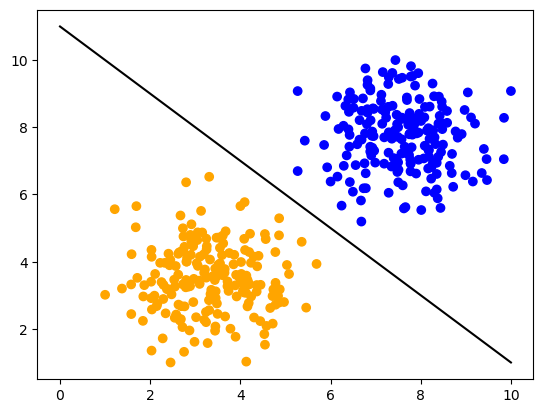

In [38]:

fig,ax=plt.subplots()
ax.scatter(x=df['Med_1_mL'],y=df["Med_2_mL"],c=df["Virus Present"],cmap=ListedColormap(["blue","orange"]));

# HYPERPLANE (2d line)

x=np.linspace(0,10,100)
m=-1
b=11
y=m*x +b

plt.plot(x,y,"black")

# Ploting scatterplot with sns

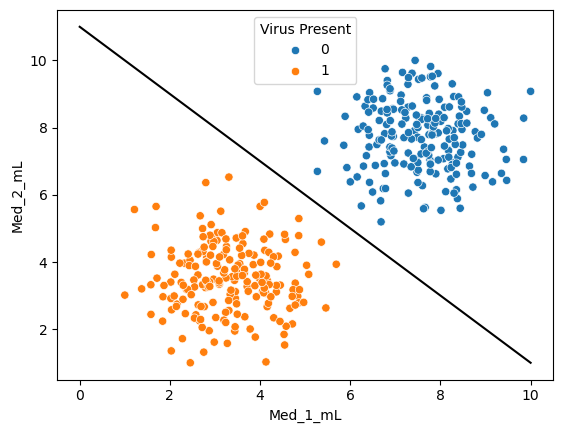

In [41]:
sns.scatterplot(data=df,x='Med_1_mL',y="Med_2_mL",hue="Virus Present");

# HYPERPLANE (2d line)

x=np.linspace(0,10,100)
m=-1
b=11
y=m*x +b

plt.plot(x,y,"black")


In [42]:
from sklearn.svm import SVC

In [53]:
X=df.drop('Virus Present',axis=1)
y=df["Virus Present"]

In [50]:
X.values[:10],y.values[:5]


(array([[6.50823109, 8.58253052],
        [4.12611616, 3.07345853],
        [6.42787048, 6.3697581 ],
        [3.67295336, 4.90521525],
        [1.58032068, 2.4405623 ],
        [2.15822377, 2.74545124],
        [8.1722235 , 7.32899487],
        [8.71965234, 6.2286183 ],
        [6.77907937, 6.63066712],
        [3.04363319, 4.64264994]]),
 array([0, 1, 0, 1, 1]))

In [44]:
model= SVC(kernel='linear',C=1000)

In [45]:
model.fit(X,y)

,C,1000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


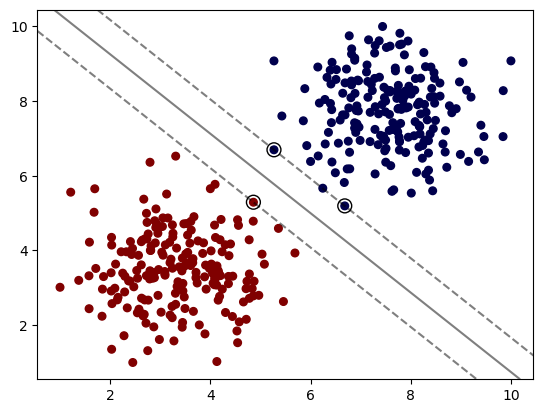

In [46]:
plot_svm_boundary(model,X,y)

In [55]:
model= SVC(kernel="linear",C=0.05)
model.fit(X,y)

,C,0.05
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


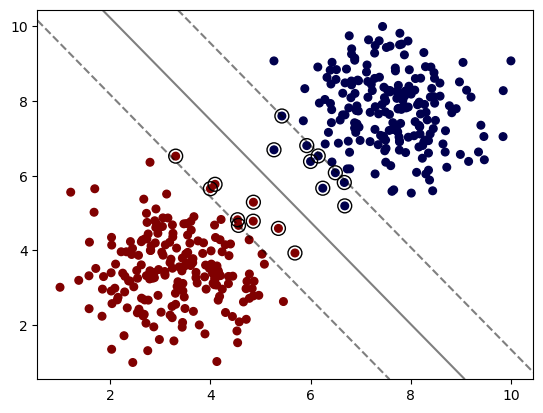

In [56]:
plot_svm_boundary(model,X,y)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


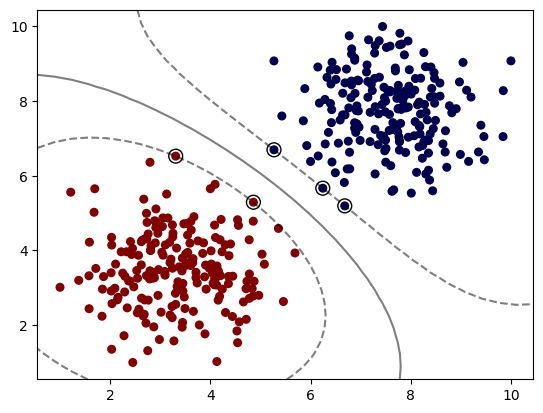

In [69]:
model= SVC(kernel="rbf",C=100,gamma=0.05)
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


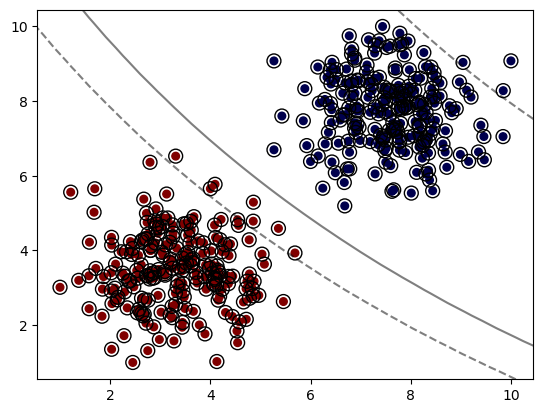

In [71]:
model= SVC(kernel="sigmoid")
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


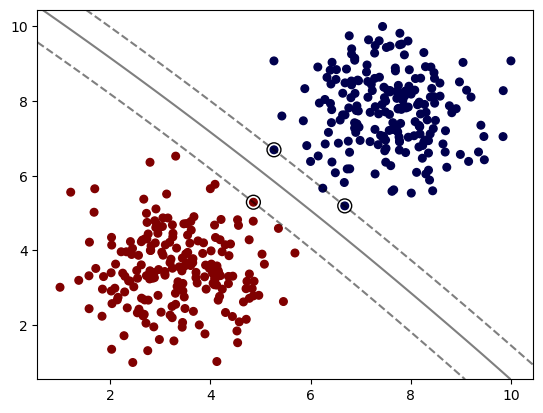

In [75]:
model= SVC(kernel="poly",degree=3)
model.fit(X,y)
plot_svm_boundary(model,X,y)

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
svm=SVC()
param_grid={"C":[0.01,0.1,1],"kernel":["linear","rbf"]}

In [78]:
grid_model=GridSearchCV(svm,param_grid=param_grid)

In [79]:
grid_model.fit(X,y)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [81]:
grid_model.best_estimator_.get_params()

{'C': 0.01,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [82]:
grid_model.best_params_

{'C': 0.01, 'kernel': 'linear'}